# Assignment

Use the "from the expert" (FTE) jupyter notebook as a starter for this assignment, and ask your instructor questions if you need help.

Use the `churn_data.csv` file to carry out a similar data cleaning and preparation as we did in the FTE. Specifically, at least complete these minimum requirements:

- Check for outliers in numeric data, and deal with them if needed
- Check for missing values, and decide how to deal with them if needed
- Convert categorical columns to numeric values
- Create at least one new feature by combining multiple columns. For example, you could calculate the ratio of total charges to tenure. Create at least one plot for your new feature.
- Save the data to a csv (or another filetype of your choice) for use next week.
- Write a short analysis at the end of the notebook describing your findings and what you did.

You can do more data cleaning, preparation, and EDA beyond these basic requirements if you want to learn more and develop your data science skills. For example, you could use a box-cox transformation on the numeric data or try other outlier methods.

### DS process status

Here is our data science process, and where we are (#3):

**1. Business understanding**

Can we use machine learning to predict if a customer will churn before they leave?

**2. Data understanding**

Done in week 1 (mostly), this is iterative so you might do more of this as we go on.

**3. Data preparation**

We are here this week.


**4. Modeling**

Next week


**5. Evaluation**

Next week


**6. Deployment**

Next week

In [15]:
'''
Importing our data
'''
import pandas as pd

df = pd.read_csv('churn_data.csv')
df

,customerID,tenure,PhoneService,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,34,Yes,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,2,Yes,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,45,No,One year,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,2,Yes,Month-to-month,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...
7038,6840-RESVB,24,Yes,One year,Mailed check,84.80,1990.50,No
7039,2234-XADUH,72,Yes,One year,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,11,No,Month-to-month,Electronic check,29.60,346.45,No
7041,8361-LTMKD,4,Yes,Month-to-month,Mailed check,74.40,306.60,Yes


In [16]:
'''
Let's get the numeric columns and then check for outliers
'''

import numpy as np

df_numeric = df.select_dtypes([np.number])
df_numeric

,tenure,MonthlyCharges,TotalCharges
0,1,29.85,29.85
1,34,56.95,1889.50
2,2,53.85,108.15
3,45,42.30,1840.75
4,2,70.70,151.65
...,...,...,...
7038,24,84.80,1990.50
7039,72,103.20,7362.90
7040,11,29.60,346.45
7041,4,74.40,306.60


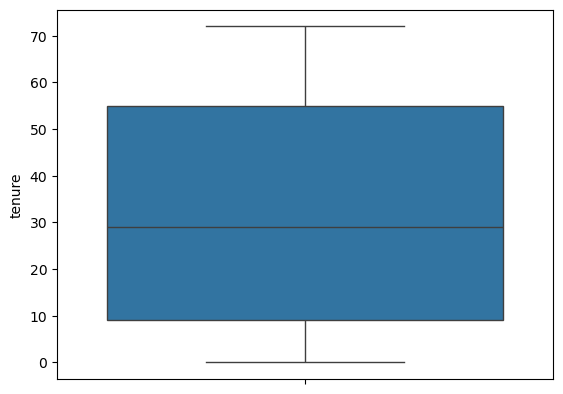

In [17]:
'''
We can get outlier in two ways; by looking at a graph or by calculating it out with math
Let's do both to get a better idea of the data
'''

import seaborn as sbn

_ = sbn.boxplot(df['tenure'])
#It seems that there are no outliers with any of the numeric data

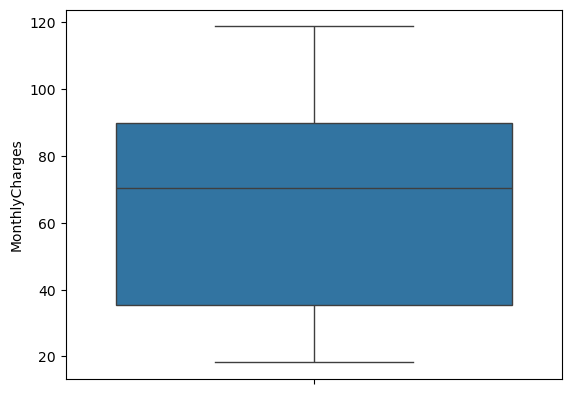

In [18]:
_ = sbn.boxplot(df['MonthlyCharges'])

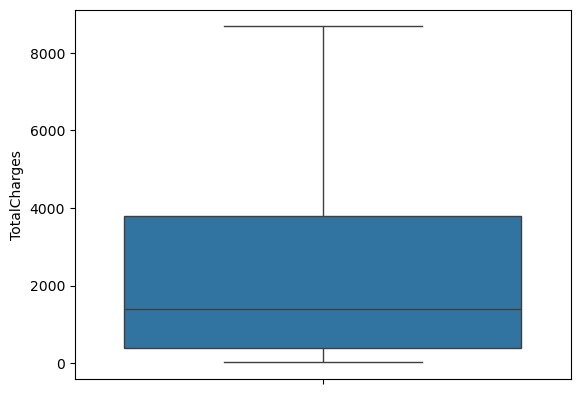

In [19]:
_ = sbn.boxplot(df['TotalCharges'])

In [20]:
'''
We can see that the Total Charges variable is the only one with missing values
Since there are hardly any missing values here, let's just drop them
'''
df.isna().sum()

customerID         0
tenure             0
PhoneService       0
Contract           0
PaymentMethod      0
MonthlyCharges     0
TotalCharges      11
Churn              0
dtype: int64

In [21]:
'''
Now we have gotten rid of our missing values from the dataframe
'''
df = df.dropna()
df.isna().sum()

customerID        0
tenure            0
PhoneService      0
Contract          0
PaymentMethod     0
MonthlyCharges    0
TotalCharges      0
Churn             0
dtype: int64

In [22]:
'''
Next we want to change all of our categorical data to have numeric values
First, let's get all the categorical columns
'''

df_categorical = df.select_dtypes(exclude=[np.number])
df_categorical

,customerID,PhoneService,Contract,PaymentMethod,Churn
0,7590-VHVEG,No,Month-to-month,Electronic check,No
1,5575-GNVDE,Yes,One year,Mailed check,No
2,3668-QPYBK,Yes,Month-to-month,Mailed check,Yes
3,7795-CFOCW,No,One year,Bank transfer (automatic),No
4,9237-HQITU,Yes,Month-to-month,Electronic check,Yes
...,...,...,...,...,...
7038,6840-RESVB,Yes,One year,Mailed check,No
7039,2234-XADUH,Yes,One year,Credit card (automatic),No
7040,4801-JZAZL,No,Month-to-month,Electronic check,No
7041,8361-LTMKD,Yes,Month-to-month,Mailed check,Yes


In [23]:
'''
Now we have to find the most appropriate way to convert each column.
Let's start with the Churn and PhoneService column, which can easily be converted to a 1 (yes) or 0 (no)
'''

df.Churn.replace({'Yes':1, 'No':0}, inplace=True)
df.PhoneService.replace({'Yes':1, 'No':0}, inplace=True)
df.head()

/var/folders/_c/phkzhjtn69l3lcd6q2xrxh8h0000gn/T/ipykernel_93207/2770294660.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.Churn.replace({'Yes':1, 'No':0}, inplace=True)
/var/folders/_c/phkzhjtn69l3lcd6q2xrxh8h0000gn/T/ipykernel_93207/2770294660.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', Tru

,customerID,tenure,PhoneService,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,0,Month-to-month,Electronic check,29.85,29.85,0
1,5575-GNVDE,34,1,One year,Mailed check,56.95,1889.50,0
2,3668-QPYBK,2,1,Month-to-month,Mailed check,53.85,108.15,1
3,7795-CFOCW,45,0,One year,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,2,1,Month-to-month,Electronic check,70.70,151.65,1


In [24]:
'''
For the other 3 categorical variables, lets one-hot label encode them
'''

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

'''
Encoding the customerID section with a unique number.
We then set the customerID to the index as that makes the most sense.
'''
df['customerID'] = label_encoder.fit_transform(df['customerID'])
df.set_index('customerID', inplace=True)


#Getting our one-hot encodings for contract and payment method
contract_onehot = pd.get_dummies(df['Contract'], dtype=int)
payment_method_onehot = pd.get_dummies(df['PaymentMethod'], dtype=int)

'''
We then drop the two columns we one-hot encoded and then concatonate
the new one-hot encoded columns with our original dataframe
'''
df.drop('Contract', axis=1, inplace=True)
df.drop('PaymentMethod', axis=1, inplace=True)
df = pd.concat([df, contract_onehot, payment_method_onehot], axis=1)

df.head()

/var/folders/_c/phkzhjtn69l3lcd6q2xrxh8h0000gn/T/ipykernel_93207/609230906.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['customerID'] = label_encoder.fit_transform(df['customerID'])
/var/folders/_c/phkzhjtn69l3lcd6q2xrxh8h0000gn/T/ipykernel_93207/609230906.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop('Contract', axis=1, inplace=True)
/var/folders/_c/phkzhjtn69l3lcd6q2xrxh8h0000gn/T/ipykernel_93207/609230906.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documenta

,tenure,PhoneService,MonthlyCharges,TotalCharges,Churn,Month-to-month,One year,Two year,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
customerID,,,,,,,,,,,,
5365,1,0,29.85,29.85,0,1,0,0,0,0,1,0
3953,34,1,56.95,1889.50,0,0,1,0,0,0,0,1
2558,2,1,53.85,108.15,1,1,0,0,0,0,0,1
5524,45,0,42.30,1840.75,0,0,1,0,1,0,0,0
6500,2,1,70.70,151.65,1,1,0,0,0,0,1,0


In [25]:
'''
We can also normalize the numeric values of monthly/total charges and tenure
We saw in the last HW assignment that none of these three variables were normally distributed 
We can use the Yeo-Johnson transform
'''
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer()

df['yj_tenure'] = pt.fit_transform(df[['tenure']])
df['yj_monthly_charges'] = pt.fit_transform(df[['MonthlyCharges']])
df['yj_total_charges'] = pt.fit_transform(df[['TotalCharges']])

df.head()

,tenure,PhoneService,MonthlyCharges,TotalCharges,Churn,Month-to-month,One year,Two year,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check,yj_tenure,yj_monthly_charges,yj_total_charges
customerID,,,,,,,,,,,,,,,
5365,1,0,29.85,29.85,0,1,0,0,0,0,1,0,-1.649511,-1.159996,-1.810069
3953,34,1,56.95,1889.50,0,0,1,0,0,0,0,1,0.294467,-0.241345,0.254257
2558,2,1,53.85,108.15,1,1,0,0,0,0,0,1,-1.500657,-0.344532,-1.386091
5524,45,0,42.30,1840.75,0,0,1,0,1,0,0,0,0.644481,-0.732875,0.233220
6500,2,1,70.70,151.65,1,1,0,0,0,0,1,0,-1.500657,0.211884,-1.248808


In [26]:
'''
Lastly, let's create a new variable that may help enlighten some more information from the data
Let's look at how much more (or less) money each customer is paying monthly for their phone bill
compared to the overall data median monthly charge
'''

df['MonthlyCharges_over_Median'] = round((df['MonthlyCharges'] - df['MonthlyCharges'].median()), 2)
df.head()

,tenure,PhoneService,MonthlyCharges,TotalCharges,Churn,Month-to-month,One year,Two year,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check,yj_tenure,yj_monthly_charges,yj_total_charges,MonthlyCharges_over_Median
customerID,,,,,,,,,,,,,,,,
5365,1,0,29.85,29.85,0,1,0,0,0,0,1,0,-1.649511,-1.159996,-1.810069,-40.50
3953,34,1,56.95,1889.50,0,0,1,0,0,0,0,1,0.294467,-0.241345,0.254257,-13.40
2558,2,1,53.85,108.15,1,1,0,0,0,0,0,1,-1.500657,-0.344532,-1.386091,-16.50
5524,45,0,42.30,1840.75,0,0,1,0,1,0,0,0,0.644481,-0.732875,0.233220,-28.05
6500,2,1,70.70,151.65,1,1,0,0,0,0,1,0,-1.500657,0.211884,-1.248808,0.35


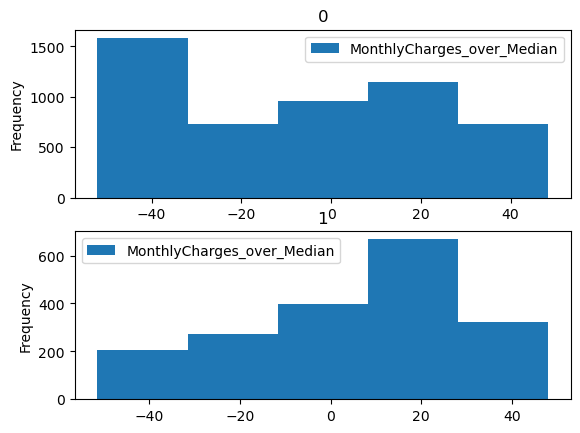

In [27]:
'''
Let's create a histogram of our new varaible sorted by Churn
'''

_ = df.plot.hist(column='MonthlyCharges_over_Median', by='Churn', bins=5)

In [28]:
'''
Finally, let's export our adjusted data to a new csv file
'''

df.to_csv('churn_cleaned.csv', index=False)

### Summary

Write your summary of the process and results here.

We have cleaned our data through dropping outliers, dealing with missing values, and encoding our categorical data.  

We found no outliers in the three numeric variables of tenure, monthly charges, and total charges.  Next, we found 11 missing values in the total charges column.  Because there are over 7000 rows of data, dropping only 11 rows will have little impact on our final data analysis, so we decided to drop those rows.  Lastly, we changed the rest of our categorical variables (phone service, contract, payment method, customer ID, and churn) to numeric values.  Churn and phone service are simple yes or no questions, so they were encoded with a 1 or 0 respectively.  The other variables were encoded with one-hot label encoding.  Then we normalized our three numeric variables.

Lastly, we created a new variable to try and extract extra information from the dataset.  We decided to look at each customer's current monthly charge compared to the overall dataset's median monthly charge.  This column gives us an idea of how much more or less each customer is paying compared to the median.  The histogram showed how this variable compares to customers who churned vs customers who did not churn.  The graph shows clearly that people who left the phone company, on average, spent more money on their monthly bill.